<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW2/HW2_LanguageProcessing_RNN_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

from torch import nn
from torch import functional as F
from torch import optim

!pip install torchinfo

import matplotlib.pyplot as plt


from torchinfo import summary



In [110]:
text_sequence = """“Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.”"""

In [111]:
torch.manual_seed(1)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#hyperparameters
lr = 0.01
epochs = 30
input_lengths = [10,20,30]
hidden_size = 100

device

device(type='cuda', index=0)

In [112]:
# We need to convert this text into a list of sorted indices for
print(f"Total Input Characters: {len(text_sequence)}")
sorted_text = list(sorted(set(text_sequence)))
print(f"Total Unique Characters: {len(sorted_text)}")
print(sorted_text)

ix_to_char = {i: ch for i,ch in enumerate(sorted_text)}
print(ix_to_char)

char_to_ix = {ch: i for i, ch in enumerate(sorted_text)}

Total Input Characters: 2393
Total Unique Characters: 47
['\n', ' ', "'", '(', ')', ',', '-', '.', 'A', 'D', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '“', '”']
{0: '\n', 1: ' ', 2: "'", 3: '(', 4: ')', 5: ',', 6: '-', 7: '.', 8: 'A', 9: 'D', 10: 'I', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'R', 17: 'S', 18: 'T', 19: 'a', 20: 'b', 21: 'c', 22: 'd', 23: 'e', 24: 'f', 25: 'g', 26: 'h', 27: 'i', 28: 'j', 29: 'k', 30: 'l', 31: 'm', 32: 'n', 33: 'o', 34: 'p', 35: 'q', 36: 'r', 37: 's', 38: 't', 39: 'u', 40: 'v', 41: 'w', 42: 'x', 43: 'y', 44: 'z', 45: '“', 46: '”'}


In [113]:
#Create Model
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN, self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.rnn = nn.RNN(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)


  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.rnn(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(LSTM,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.dropout = nn.Dropout(p=0.5)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.lstm(embedded)
    output = self.fc1(output[:, -1, :])
    return output

class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(GRU,self).__init__()
    self.embedding = nn.Embedding(input_size, hidden_size)
    self.gru = nn.GRU(input_size = hidden_size, hidden_size=hidden_size, batch_first = True)
    self.dropout = nn.Dropout(p=0.5)
    self.fc1 = nn.Linear(in_features = hidden_size, out_features = output_size)

  def forward(self, x):
    embedded = self.embedding(x)
    output,_ = self.gru(embedded)
    output = self.fc1(output[:, -1, :])
    return output

In [114]:
#Splitting into train and test datasets
from sklearn.model_selection import train_test_split
def preprocess_text(text, sequence_length):
    # Preparing the dataset
    max_length = sequence_length  # Maximum length of input sequences
    X = []
    y = []
    for i in range(len(text) - max_length):
        sequence = text[i:i + max_length]
        label = text[i + max_length]
        X.append([char_to_ix[char] for char in sequence])
        y.append(char_to_ix[label])

    X = np.array(X)
    y = np.array(y)

    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.10, random_state=1
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=15/90, random_state=1
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [115]:
def createPlot(sequence_length, train_loss_list, val_loss_list, val_accuracy_list):
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(train_loss_list, label='Train Loss')
  plt.plot(val_loss_list, label='Val Loss')
  plt.title(f'Loss Curves Sequence Length:{sequence_length}')
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(val_accuracy_list, label='Val Accuracy')
  plt.title(f'Validation Accuracy Sequence Length:{sequence_length}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy (%)')
  plt.legend()

  plt.show()

In [116]:
def createMODELandLOSS(model):
  model = model.upper()
  valid_models = {'RNN', 'LSTM', 'GRU'}
  if model not in valid_models:
    raise ValueError(f"Invalid Type {model}. Expected one of {valid_models}")
  if(model == "RNN"):
    model = RNN(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "LSTM"):
    model = LSTM(len(sorted_text), hidden_size, len(sorted_text)).to(device)
  elif(model == "GRU"):
    model = GRU(len(sorted_text), hidden_size, len(sorted_text)).to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr = lr)
  return model, criterion, optimizer

In [121]:
def run(modelName):
##Data Preprocessing and converting to tensor
  for i, input_length in enumerate(input_lengths):
    model, criterion, optimizer = createMODELandLOSS(modelName)

    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_text(text_sequence, input_length)

    X_train = torch.tensor(X_train, dtype=torch.long).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val = torch.tensor(X_val, dtype=torch.long).to(device)
    y_val = torch.tensor(y_val, dtype=torch.long).to(device)
    X_test = torch.tensor(X_test, dtype=torch.long).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)





    ###This is where training begins
    #Lists for storing loss and validation values
    train_loss_list = []
    val_loss_list = []
    val_accuracy_list = []


    #Create a new training loop for each input_length

    for epoch in range(epochs):
      start_event = torch.cuda.Event(enable_timing=True)
      end_event = torch.cuda.Event(enable_timing=True)
      start_event.record()
      model.train()

      optimizer.zero_grad()
      y_pred = model(X_train)  # Forward pass
      loss = criterion(y_pred, y_train)  # Compute loss
      loss.backward()  # Backward pass
      optimizer.step()  # Update model parameters

      train_loss_list.append(loss.item()) #Take this epoch's training loss and add it
                                          #to the training loss list (of all epochs)

      end_event.record()

      torch.cuda.synchronize()

                                        # Calculate time in milliseconds
      elapsed_time_ms = start_event.elapsed_time(end_event)
      print(f"Training time for one epoch: {elapsed_time_ms / 1000:.6f} seconds")


      #Here is where we evaluate the model on the current epoch
      model.eval()
      with torch.no_grad():
        val_output = model(X_val) # Take test dataset and run it through this epoch's model

        val_loss = criterion(val_output, y_val) #Find the loss

        _, predicted = torch.max(val_output, 1) #Here we find what the output was (what letter)

        val_accuracy = (predicted == y_val).float().mean() #Here we take each answer from our model,
                                                          #compare it to the ground truth, and find how accurate we are

        val_loss_list.append(val_loss.item())
        val_accuracy_list.append(val_accuracy.item())


        print(f'Epoch {epoch}, Loss: {loss.item():.4f}, Val Accuracy: {val_accuracy.item():.4f}, Val Loss: {val_loss.item():.4f}')

    createPlot(input_length, train_loss_list, val_loss_list, val_accuracy_list)
    print(summary(model, input_size = (1,input_length), dtypes=[torch.long]))

    print("running test set evaluation")
    model.eval()
    with torch.no_grad():
      test_output = model(X_test)
      test_loss = criterion(test_output, y_test)
      _, predicted = torch.max(test_output, 1)
      test_accuracy = (predicted == y_test).float().mean()
      print(f"Final Test Accuracy: {100 * test_accuracy:.4f}%")



Training time for one epoch: 0.004825 seconds
Epoch 0, Loss: 3.8829, Val Accuracy: 0.2039, Val Loss: 3.3704
Training time for one epoch: 0.002417 seconds
Epoch 1, Loss: 3.3454, Val Accuracy: 0.2235, Val Loss: 2.9327
Training time for one epoch: 0.002247 seconds
Epoch 2, Loss: 2.9055, Val Accuracy: 0.3156, Val Loss: 2.6289
Training time for one epoch: 0.002227 seconds
Epoch 3, Loss: 2.6213, Val Accuracy: 0.3268, Val Loss: 2.4958
Training time for one epoch: 0.002323 seconds
Epoch 4, Loss: 2.4871, Val Accuracy: 0.3520, Val Loss: 2.3978
Training time for one epoch: 0.002231 seconds
Epoch 5, Loss: 2.3770, Val Accuracy: 0.3911, Val Loss: 2.3341
Training time for one epoch: 0.002227 seconds
Epoch 6, Loss: 2.2836, Val Accuracy: 0.3994, Val Loss: 2.2873
Training time for one epoch: 0.002196 seconds
Epoch 7, Loss: 2.1953, Val Accuracy: 0.3939, Val Loss: 2.2551
Training time for one epoch: 0.002190 seconds
Epoch 8, Loss: 2.1198, Val Accuracy: 0.4050, Val Loss: 2.2313
Training time for one epoch:

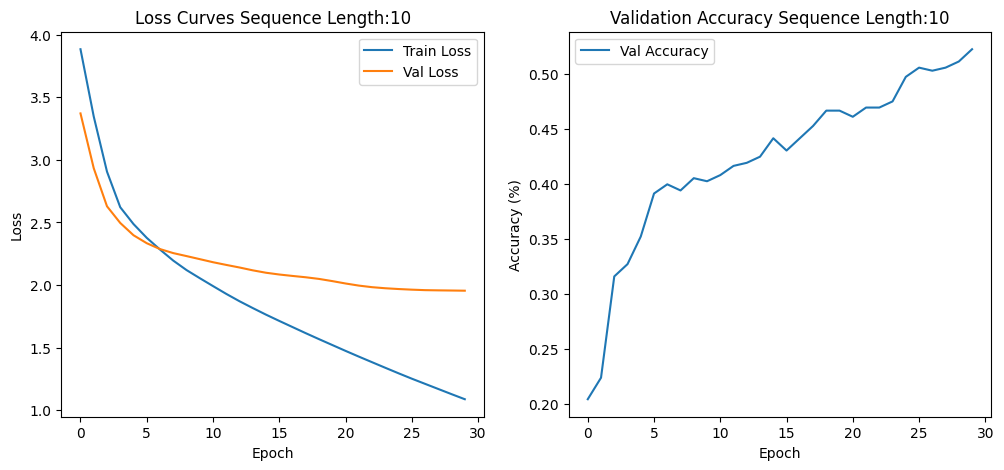

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 10, 100]              4,700
├─RNN: 1-2                               [1, 10, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.21
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.12
Estimated Total Size (MB): 0.14
running test set evaluation
Final Test Accuracy: 46.8619%
Training time for one epoch: 0.003261 seconds
Epoch 0, Loss: 3.8636, Val Accuracy: 0.2191, Val Loss: 3.3443
Training time for one epoch: 0.002450 seconds
Epoch 1, Loss: 3.2774, Val Accuracy: 0.2893, Val Loss: 2.9032
Training time for one epoch: 0.002256 seconds
Epoch 2, Loss: 2.8107, Val Accuracy: 0.2472, Val Loss: 2.7082
Training time for one epoch:

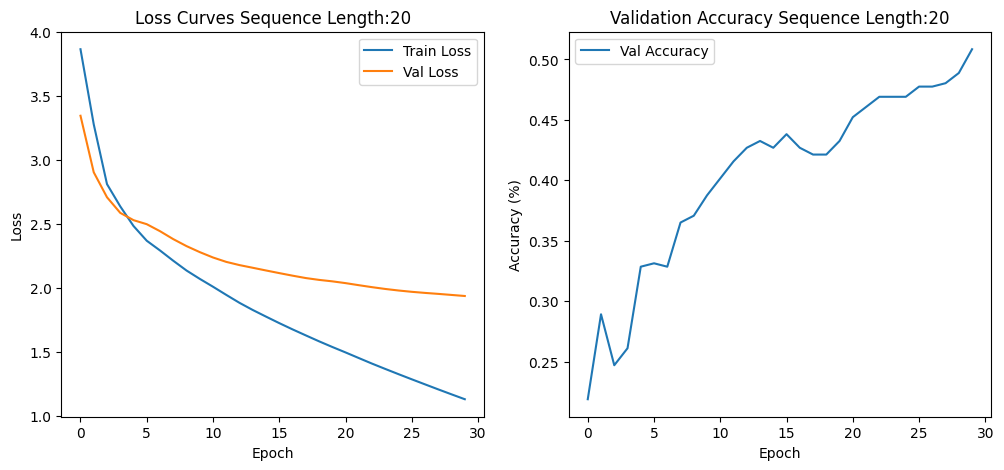

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─RNN: 1-2                               [1, 20, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.41
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.12
Estimated Total Size (MB): 0.15
running test set evaluation
Final Test Accuracy: 48.7395%
Training time for one epoch: 0.003402 seconds
Epoch 0, Loss: 3.9184, Val Accuracy: 0.1775, Val Loss: 3.4647
Training time for one epoch: 0.002475 seconds
Epoch 1, Loss: 3.3976, Val Accuracy: 0.2394, Val Loss: 3.0481
Training time for one epoch: 0.002290 seconds
Epoch 2, Loss: 2.9520, Val Accuracy: 0.2732, Val Loss: 2.7537
Training time for one epoch:

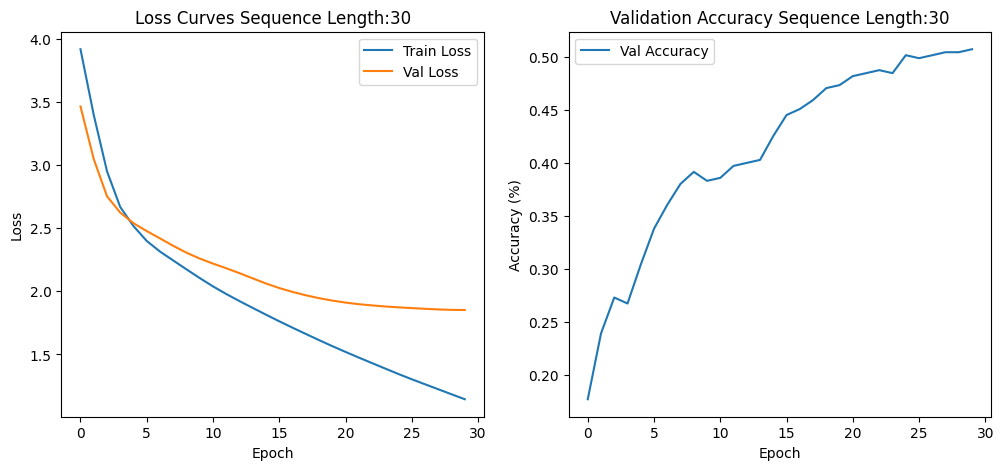

Layer (type:depth-idx)                   Output Shape              Param #
RNN                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 30, 100]              4,700
├─RNN: 1-2                               [1, 30, 100]              20,200
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 29,647
Trainable params: 29,647
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.62
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.12
Estimated Total Size (MB): 0.17
running test set evaluation
Final Test Accuracy: 49.3671%


In [122]:
run("RNN")

#Results Vanilla-RNN

No Dropout, 30 epochs, sequence length 10: Loss: 1.1452, Val Accuracy: 0.4916, Val Loss: 1.9447

No Dropout, 30 epochs, sequence length 20: Loss: 1.1761, Val Accuracy: 0.5084, Val Loss: 1.9504

No Dropout, 30 epochs, sequence length 30: Loss: 1.1973, Val Accuracy: 0.4986, Val Loss: 1.8462

p = 0.3 Dropout, 30 epochs, sequence length 10: Loss: 1.4008, Val Accuracy: 0.4916, Val Loss: 1.9773

p = 0.3 Dropout, 30 epochs, sequence length 20:  Loss: 1.3887, Val Accuracy: 0.4775, Val Loss: 1.9237

p = 0.3 Dropout, 30 epochs, sequence length 30: Loss: 1.4059, Val Accuracy: 0.5042, Val Loss: 1.8758

p = 0.5 Dropout, 30 epochs, sequence length 10: Loss: 1.5628, Val Accuracy: 0.4832, Val Loss: 1.9449

p = 0.5 Dropout, 30 epochs, sequence length 20: Loss: 1.6070, Val Accuracy: 0.4831, Val Loss: 1.9532

p = 0.5 Dropout, 30 epochs, sequence length 30: Loss: 1.6470, Val Accuracy: 0.4930, Val Loss: 1.8554


Based purely on accuracy from the validation dataset, the model with sequence length 20, with no dropout performed the best.

Final Test Accuracy: 48.3193%

Training time for one epoch: 0.003617 seconds
Epoch 0, Loss: 3.8753, Val Accuracy: 0.2654, Val Loss: 3.6278
Training time for one epoch: 0.002801 seconds
Epoch 1, Loss: 3.6283, Val Accuracy: 0.2933, Val Loss: 3.2592
Training time for one epoch: 0.002784 seconds
Epoch 2, Loss: 3.2664, Val Accuracy: 0.2877, Val Loss: 2.9044
Training time for one epoch: 0.002799 seconds
Epoch 3, Loss: 2.9383, Val Accuracy: 0.2374, Val Loss: 2.7833
Training time for one epoch: 0.002799 seconds
Epoch 4, Loss: 2.8354, Val Accuracy: 0.2542, Val Loss: 2.7041
Training time for one epoch: 0.002809 seconds
Epoch 5, Loss: 2.7350, Val Accuracy: 0.2821, Val Loss: 2.6122
Training time for one epoch: 0.002779 seconds
Epoch 6, Loss: 2.6154, Val Accuracy: 0.3240, Val Loss: 2.5407
Training time for one epoch: 0.002769 seconds
Epoch 7, Loss: 2.5159, Val Accuracy: 0.3073, Val Loss: 2.4832
Training time for one epoch: 0.002805 seconds
Epoch 8, Loss: 2.4293, Val Accuracy: 0.3380, Val Loss: 2.4315
Training time for one epoch:

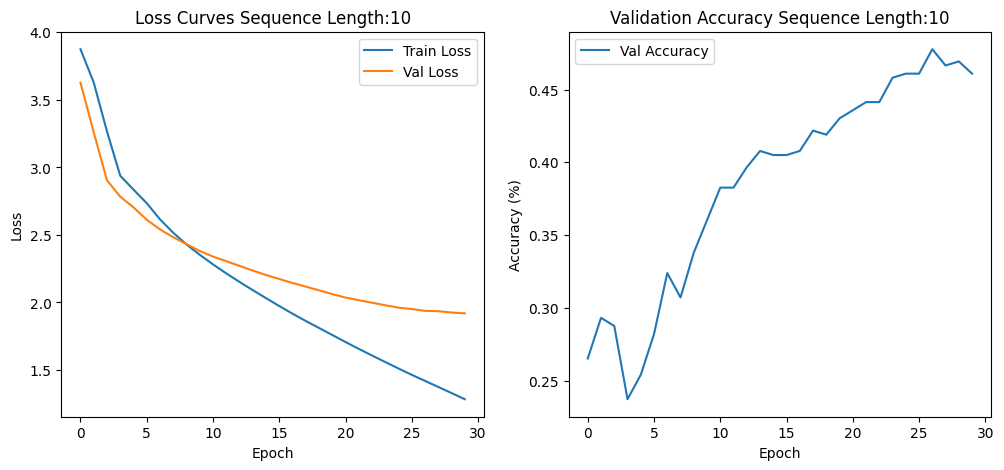

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 10, 100]              4,700
├─LSTM: 1-2                              [1, 10, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.82
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.36
Estimated Total Size (MB): 0.38
running test set evaluation
Final Test Accuracy: 47.2803%
Training time for one epoch: 0.004254 seconds
Epoch 0, Loss: 3.8668, Val Accuracy: 0.1770, Val Loss: 3.6376
Training time for one epoch: 0.004081 seconds
Epoch 1, Loss: 3.6081, Val Accuracy: 0.1713, Val Loss: 3.2722
Training time for one epoch: 0.004078 seconds
Epoch 2, Loss: 3.2186, Val Accuracy: 0.1713, Val Loss: 2.9985
Training time for one epoch:

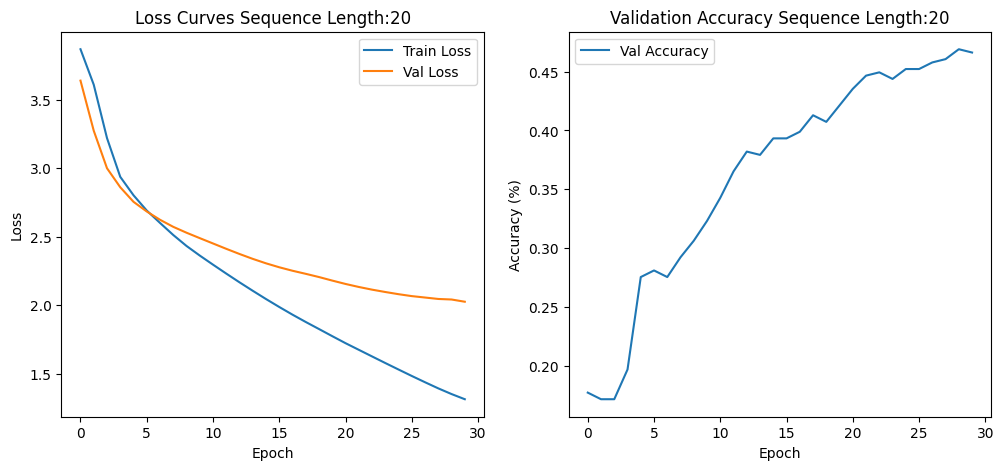

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─LSTM: 1-2                              [1, 20, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.63
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.36
Estimated Total Size (MB): 0.39
running test set evaluation
Final Test Accuracy: 46.6387%
Training time for one epoch: 0.004655 seconds
Epoch 0, Loss: 3.8338, Val Accuracy: 0.2141, Val Loss: 3.5409
Training time for one epoch: 0.004445 seconds
Epoch 1, Loss: 3.5228, Val Accuracy: 0.2000, Val Loss: 3.1144
Training time for one epoch: 0.004460 seconds
Epoch 2, Loss: 3.0892, Val Accuracy: 0.2085, Val Loss: 2.9397
Training time for one epoch:

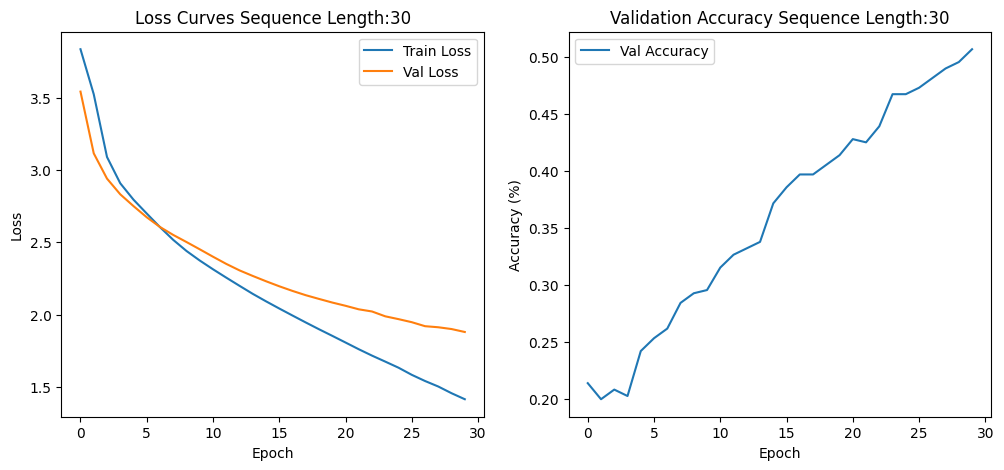

Layer (type:depth-idx)                   Output Shape              Param #
LSTM                                     [1, 47]                   --
├─Embedding: 1-1                         [1, 30, 100]              4,700
├─LSTM: 1-2                              [1, 30, 100]              80,800
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 90,247
Trainable params: 90,247
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.43
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.36
Estimated Total Size (MB): 0.41
running test set evaluation
Final Test Accuracy: 48.1013%


In [123]:
run("LSTM")

#Results LSTM
No Dropout, 30 epochs, sequence length 10: Loss: 1.3108, Val Accuracy: 0.5084, Val Loss: 1.8900

No Dropout, 30 epochs, sequence length 20: Loss: 1.3024, Val Accuracy: 0.4691, Val Loss: 2.0127

No Dropout, 30 epochs, sequence length 30: Loss: 1.3169, Val Accuracy: 0.5042, Val Loss: 1.8474

p=0.3 Dropout, 30 epochs, sequence length 10: Loss: 1.5570, Val Accuracy: 0.4358, Val Loss: 1.9922

p=0.3 Dropout, 30 epochs, sequence length 20: Loss: 1.6145, Val Accuracy: 0.4691, Val Loss: 2.0054

p=0.3 Dropout, 30 epochs, sequence length 30: Loss: 1.6126, Val Accuracy: 0.4563, Val Loss: 1.9068

p=0.5 Dropout, 30 epochs, sequence length 10: Loss: 1.7433, Val Accuracy: 0.4693, Val Loss: 1.9656

p=0.5 Dropout, 30 epochs, sequence length 10: Loss: 1.7433, Val Accuracy: 0.4693, Val Loss: 1.9656

p=0.5 Dropout, 30 epochs, sequence length 10: Loss: 1.7306, Val Accuracy: 0.4592, Val Loss: 1.9290

Based purely on accuracy from the validation dataset, the model with sequence length 10, with no dropout performed the best.

Final Test Accuracy: 46.8619%

Training time for one epoch: 0.003567 seconds
Epoch 0, Loss: 3.8675, Val Accuracy: 0.2011, Val Loss: 3.4833
Training time for one epoch: 0.002562 seconds
Epoch 1, Loss: 3.4676, Val Accuracy: 0.2095, Val Loss: 3.0685
Training time for one epoch: 0.002478 seconds
Epoch 2, Loss: 3.0535, Val Accuracy: 0.2514, Val Loss: 2.8050
Training time for one epoch: 0.002525 seconds
Epoch 3, Loss: 2.7937, Val Accuracy: 0.2486, Val Loss: 2.7030
Training time for one epoch: 0.002672 seconds
Epoch 4, Loss: 2.6780, Val Accuracy: 0.2821, Val Loss: 2.5999
Training time for one epoch: 0.002338 seconds
Epoch 5, Loss: 2.5512, Val Accuracy: 0.3184, Val Loss: 2.5148
Training time for one epoch: 0.002639 seconds
Epoch 6, Loss: 2.4398, Val Accuracy: 0.3296, Val Loss: 2.4470
Training time for one epoch: 0.002300 seconds
Epoch 7, Loss: 2.3468, Val Accuracy: 0.3575, Val Loss: 2.3821
Training time for one epoch: 0.002338 seconds
Epoch 8, Loss: 2.2586, Val Accuracy: 0.3687, Val Loss: 2.3212
Training time for one epoch:

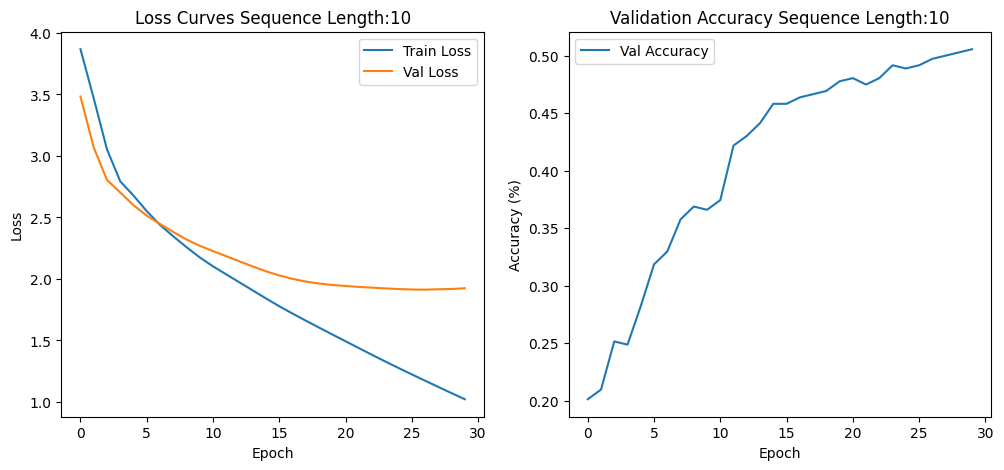

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 10, 100]              4,700
├─GRU: 1-2                               [1, 10, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.62
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.28
Estimated Total Size (MB): 0.30
running test set evaluation
Final Test Accuracy: 47.6987%
Training time for one epoch: 0.003689 seconds
Epoch 0, Loss: 3.8632, Val Accuracy: 0.1713, Val Loss: 3.4992
Training time for one epoch: 0.003186 seconds
Epoch 1, Loss: 3.4620, Val Accuracy: 0.2022, Val Loss: 3.0914
Training time for one epoch: 0.003195 seconds
Epoch 2, Loss: 3.0312, Val Accuracy: 0.2275, Val Loss: 2.8662
Training time for one epoch:

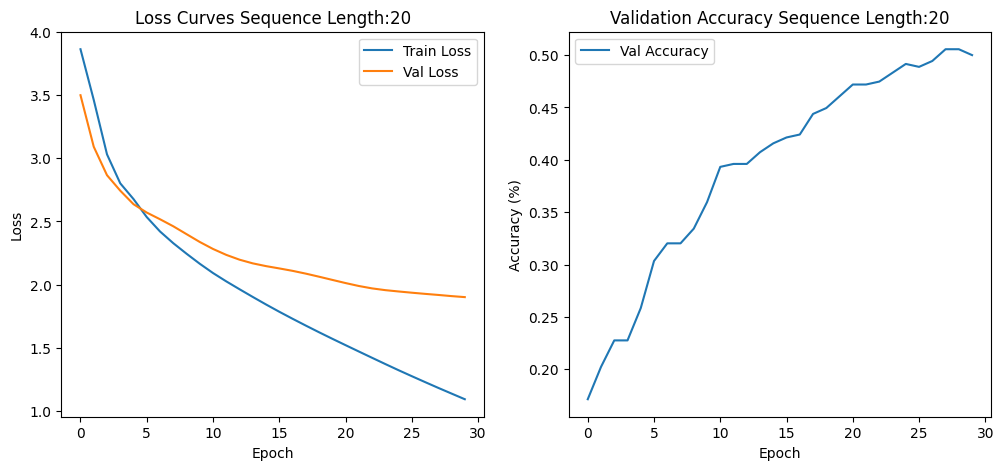

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 20, 100]              4,700
├─GRU: 1-2                               [1, 20, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.22
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.28
Estimated Total Size (MB): 0.31
running test set evaluation
Final Test Accuracy: 51.6807%
Training time for one epoch: 0.003928 seconds
Epoch 0, Loss: 3.8588, Val Accuracy: 0.2028, Val Loss: 3.4449
Training time for one epoch: 0.003844 seconds
Epoch 1, Loss: 3.4196, Val Accuracy: 0.2113, Val Loss: 2.9998
Training time for one epoch: 0.003846 seconds
Epoch 2, Loss: 2.9573, Val Accuracy: 0.1944, Val Loss: 2.8263
Training time for one epoch:

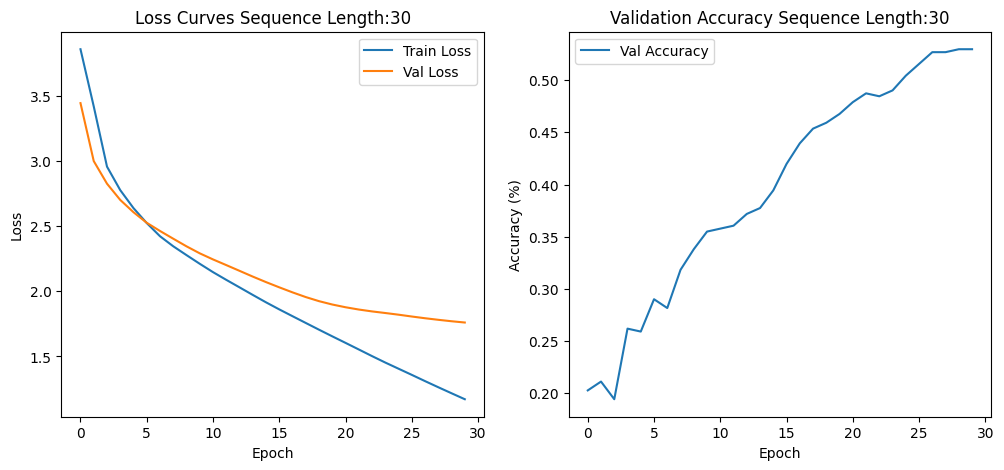

Layer (type:depth-idx)                   Output Shape              Param #
GRU                                      [1, 47]                   --
├─Embedding: 1-1                         [1, 30, 100]              4,700
├─GRU: 1-2                               [1, 30, 100]              60,600
├─Linear: 1-3                            [1, 47]                   4,747
Total params: 70,047
Trainable params: 70,047
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.83
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.28
Estimated Total Size (MB): 0.33
running test set evaluation
Final Test Accuracy: 51.8987%


In [124]:
run("GRU")

#Results GRU

No Dropout, 30 epochs, sequence length 10: Loss: 1.0899, Val Accuracy: 0.5223, Val Loss: 1.9147

No Dropout, 30 epochs, sequence length 20: Loss: 1.1004, Val Accuracy: 0.5281, Val Loss: 1.9102

No Dropout, 30 epochs, sequence length 30: Loss: 1.1599, Val Accuracy: 0.5352, Val Loss: 1.7794

p=0.3 Dropout, 30 epochs, sequence length 10: Loss: 1.3548, Val Accuracy: 0.5000, Val Loss: 1.8847

p=0.3 Dropout, 30 epochs, sequence length 20: Loss: 1.3886, Val Accuracy: 0.4803, Val Loss: 1.8825

p=0.3 Dropout, 30 epochs, sequence length 30: Loss: 1.4170, Val Accuracy: 0.5014, Val Loss: 1.7970

p=0.5 Dropout, 30 epochs, sequence length 10: Loss: 1.6076, Val Accuracy: 0.4944, Val Loss: 1.8977

p=0.5 Dropout, 30 epochs, sequence length 20: Loss: 1.6081, Val Accuracy: 0.4972, Val Loss: 1.9736

p=0.5 Dropout, 30 epochs, sequence length 30: Loss: 1.6053, Val Accuracy: 0.4930, Val Loss: 1.8630

Based purely on accuracy from the validation dataset, the model with sequence length 30, with no dropout performed the best.

Final Test Accuracy: 48.5232%